<div align="center">

<h2 style="color:#E50914;">
<strong><em>Netflix: Business Insights</em></strong>
</h2>

</div>

In [47]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Visualization settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [48]:
df = pd.read_csv('../data/netflix_cleaned.csv')

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year,added_month,added_month_name,duration_value,duration_minutes,seasons,content_age,maturity_bucket
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0,September,90.0,90.0,NaN,1.0,Teens / YA
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0,September,2.0,NaN,2.0,0.0,Mature / Adult
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0,September,1.0,NaN,1.0,0.0,Mature / Adult
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0,September,1.0,NaN,1.0,0.0,Mature / Adult
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0,September,2.0,NaN,2.0,0.0,Mature / Adult


#### Q.1 Total Netflix Titles 

In [49]:
total_titles = df["title"].nunique()

print("Total Netflix Titles:", total_titles)

Total Netflix Titles: 8807


#### Q.2 Movies vs TV Shows

In [50]:
type_counts = df["type"].value_counts()

print(type_counts)

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [51]:
type_percentage = df["type"].value_counts(normalize=True).mul(100).round(2)

print(type_percentage)


type
Movie      69.62
TV Show    30.38
Name: proportion, dtype: float64


#### Q.3 Which Content Type Dominates?

In [52]:
dominate_type = df["type"].value_counts().idxmax()

print("Dominant Content Type: ", dominate_type)

Dominant Content Type:  Movie


#### Q.4 Which Year had the Most Content Added?

In [53]:
content_by_year = df["added_year"].value_counts().sort_index()

peak_year = content_by_year.idxmax()
peak_count = content_by_year.max()

print("Peak Year:", peak_year)
print("Titles added:", peak_count)

Peak Year: 2019.0
Titles added: 2016


#### Q.5 Which Year had the Fewest Additions?

In [54]:
lowest_year = content_by_year.idxmin()
lowest_count = content_by_year.min()

print("Lowest Year:", lowest_year)
print("Titles added:", lowest_count)

Lowest Year: 2010.0
Titles added: 1


#### Q.6 Which Month has the Most Additions?

In [55]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_additions = df['added_month_name'].value_counts().reindex(month_order)

print(monthly_additions)

added_month_name
January      738
February     563
March        742
April        764
May          632
June         728
July         827
August       755
September    770
October      760
November     705
December     813
Name: count, dtype: int64


In [56]:
print(
    "Most Common Month:", monthly_additions.idxmax()
)

print(
    "Titles added:", monthly_additions.max()
)

Most Common Month: July
Titles added: 827


#### Q.7 What is the Most Common Rating?

In [57]:
rating_counts = df["rating"].value_counts()

most_common_rating = rating_counts.idxmax()

print("Most Common Rating:", most_common_rating)
print("Number of Titles:", rating_counts.max())

Most Common Rating: TV-MA
Number of Titles: 3207


#### Q.8 Rating Distribution by Type

In [58]:
rating_type = df.groupby(["rating", "type"]).size().unstack(fill_value=0)

rating_type

type,Movie,TV Show
rating,,
66 min,1,0
74 min,1,0
84 min,1,0
G,41,0
NC-17,3,0
NR,75,5
PG,287,0
PG-13,490,0
R,797,2


In [59]:
movie_rating = df[df["type"]=="Movie"]["rating"].value_counts()

tv_rating = df[df["type"]=="TV Show"]["rating"].value_counts()

print("Most Common Movie Rating:", movie_rating.idxmax())
print("Most Common TV Show Rating:", tv_rating.idxmax())

Most Common Movie Rating: TV-MA
Most Common TV Show Rating: TV-MA


#### Q.9 What is the Most Popular Genre?

In [67]:
genre_df = df.copy()

genre_df["genre"] = genre_df["listed_in"].str.split(', ')

genre_exploded = genre_df.explode("genre")

genre_counts = genre_exploded["genre"].value_counts()

In [68]:
print("Most Popular Genre:", genre_counts.idxmax())
print("Number of Titles:", genre_counts.max())

Most Popular Genre: International Movies
Number of Titles: 2752


#### Q.10 Top 10 Genre

In [63]:
top_10_genre = genre_counts.head(10)

top_10_genre

genre
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

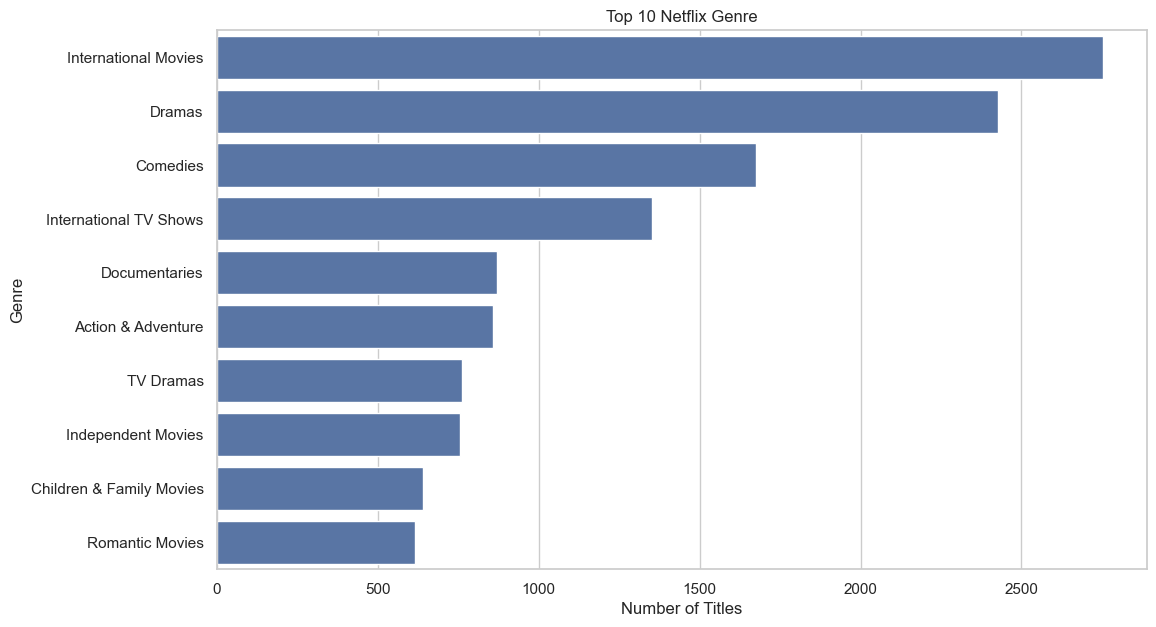

In [64]:
plt.figure(figsize=(12,7))

sns.barplot(
    x=top_10_genre.values,
    y=top_10_genre.index
)

plt.title("Top 10 Netflix Genre")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

#### Q.11 Which Genre are Movie-Dominated?

In [74]:
genre_type = genre_exploded.groupby(["genre", "type"]).size().unstack(fill_value=0)

genre_type["Movie %"] = (
    genre_type["Movie"] / genre_type[["Movie", "TV Show"]].sum(axis=1)*100
)

genre_type.sort_values("Movie %", ascending=False).head(10)

type,Movie,TV Show,Movie %
genre,,,
Action & Adventure,859,0,100.0
Anime Features,71,0,100.0
Children & Family Movies,641,0,100.0
Cult Movies,71,0,100.0
Comedies,1674,0,100.0
Classic Movies,116,0,100.0
Horror Movies,357,0,100.0
Faith & Spirituality,65,0,100.0
Dramas,2427,0,100.0


#### Q.12 Which Genres are TV-Show Dominated?

In [76]:
genre_type["TV Show %"] = (
        genre_type["TV Show"] / genre_type[["Movie", "TV Show"]].sum(axis=1)*100
)

genre_type.sort_values(
    "TV Show %",
    ascending=False
).head(10)

type,Movie,TV Show,Movie %,TV Show %
genre,,,,
British TV Shows,0,253,0.0,100.0
Anime Series,0,176,0.0,100.0
Classic & Cult TV,0,28,0.0,100.0
Crime TV Shows,0,470,0.0,100.0
Romantic TV Shows,0,370,0.0,100.0
Reality TV,0,255,0.0,100.0
Kids' TV,0,451,0.0,100.0
Korean TV Shows,0,151,0.0,100.0
International TV Shows,0,1351,0.0,100.0


#### Q.13 Which Country Produces the Most Content?

In [77]:
country_df = df.copy()

country_df["country_list"] = country_df["country"].str.split(', ')

country_exploded = country_df.explode('country_list')

country_counts = country_exploded["country_list"].value_counts()

In [78]:
print("Top Country:", country_counts.idxmax())
print("Number of Titles:", country_counts.max())

Top Country: United States
Number of Titles: 3689


#### Q.14 Top 10 Content-Producing Countries

In [79]:
top_10_countries = country_counts.head(10)

top_10_countries

country_list
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64

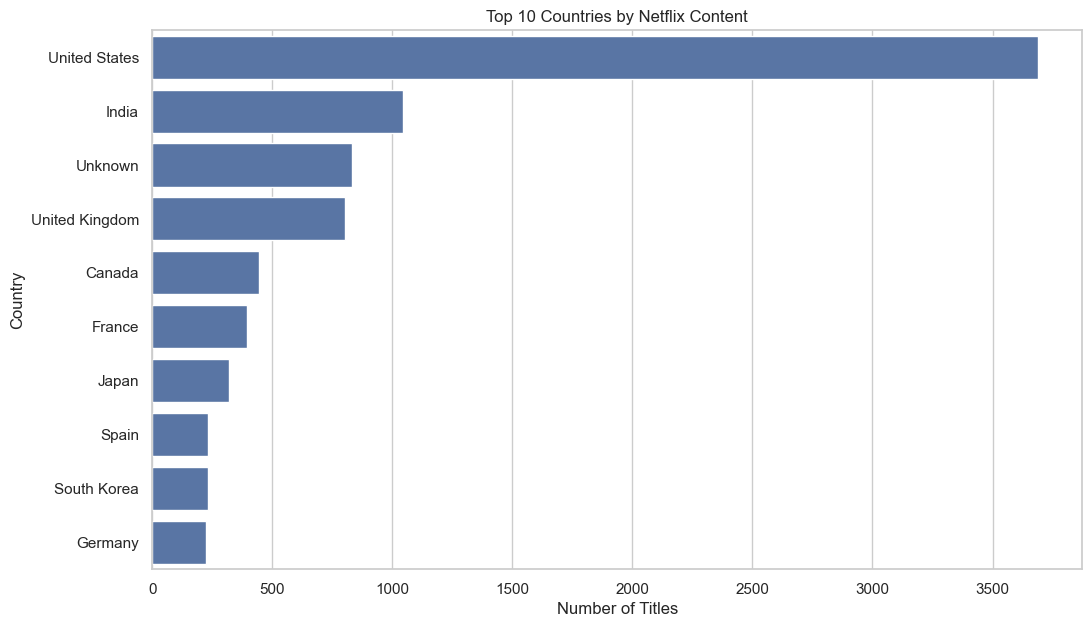

In [80]:
plt.figure(figsize=(12,7))

sns.barplot(
    x=top_10_countries.values,
    y=top_10_countries.index
)

plt.title("Top 10 Countries by Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

#### Q.15 Which Country Produce More Movies?

In [81]:
country_type = country_exploded.groupby(["country_list", "type"]).size().unstack(fill_value=0)

country_type.sort_values(
    by="Movie",
    ascending=False
).head(10)

type,Movie,TV Show
country_list,,
United States,2751,938
India,962,84
United Kingdom,532,272
Unknown,440,391
Canada,319,126
France,303,90
Germany,182,44
Spain,171,61
Japan,119,199


#### Q.16 Which Country Produce More TV Shows

In [83]:
country_type.sort_values(
    by="TV Show",
    ascending=False
).head(10)

type,Movie,TV Show
country_list,,
United States,2751,938
Unknown,440,391
United Kingdom,532,272
Japan,119,199
South Korea,61,170
Canada,319,126
France,303,90
India,962,84
Taiwan,19,70


#### Q.17 Movie vs TV Show share by Country

In [84]:
country_share = country_type.copy()

country_share["Total"] = country_share["Movie"]+country_share["TV Show"]

country_share["Movie %"] = (
    country_share["Movie"] / 
    country_share["Total"]*100
)

country_share["TV Show %"] = (
    country_share["TV Show"] /
    country_share["Total"]*100
)

In [85]:
country_share.sort_values(
    by="Total",
    ascending=False
).head(15)

type,Movie,TV Show,Total,Movie %,TV Show %
country_list,,,,,
United States,2751,938,3689,74.573055,25.426945
India,962,84,1046,91.969407,8.030593
Unknown,440,391,831,52.948255,47.051745
United Kingdom,532,272,804,66.169154,33.830846
Canada,319,126,445,71.685393,28.314607
France,303,90,393,77.099237,22.900763
Japan,119,199,318,37.421384,62.578616
Spain,171,61,232,73.706897,26.293103
South Korea,61,170,231,26.406926,73.593074


#### Most Frequent Director

In [86]:
director_df = df[df["director"] != "Unknown"].copy()

director_df["director_list"] = director_df["director"].str.split(", ")

director_exploded = director_df.explode("director_list")

director_counts = director_exploded["director_list"].value_counts()

In [87]:
top_director = director_counts.idxmax()

print("Most Frequent Director:", top_director)
print("Number of Title:", director_counts.max())

Most Frequent Director: Rajiv Chilaka
Number of Title: 22


#### Q.19 Most Frequent Actor

In [88]:
cast_df = df[df["cast"] != "Unknown"].copy()

cast_df["cast_list"] = cast_df["cast"].str.split(", ")

cast_exploded = cast_df.explode("cast_list")

actor_counts = cast_exploded["cast_list"].value_counts()

In [89]:
top_actor = actor_counts.idxmax()

print("Most frequent actor:", top_actor)
print("Number of titles:", actor_counts.max())

Most frequent actor: Anupam Kher
Number of titles: 43


In [90]:
actor_counts.head(10)

cast_list
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Takahiro Sakurai    32
Naseeruddin Shah    32
Rupa Bhimani        31
Om Puri             30
Akshay Kumar        30
Yuki Kaji           29
Amitabh Bachchan    28
Name: count, dtype: int64

#### Q.20 Average Movie Duration

In [91]:
movies = df[df["type"] == "Movie"].copy()

In [92]:
average_movie_duration = movies["duration_minutes"].mean()

median_movie_duration = movies["duration_minutes"].median()

print(
    f"Average movie duration: "
    f"{average_movie_duration:.2f} minutes"
)

print(
    f"Median movie duration: "
    f"{median_movie_duration:.2f} minutes"
)

Average movie duration: 99.58 minutes
Median movie duration: 98.00 minutes


#### Q.21 Longest Movies

In [93]:
longest_movies = (
    movies
    .sort_values(
        "duration_minutes",
        ascending=False
    )
    [["title", "duration_minutes"]]
    .head(10)
)

longest_movies

,title,duration_minutes
4253,Black Mirror: Bandersnatch,312.0
717,Headspace: Unwind Your Mind,273.0
2491,The School of Mischief,253.0
2487,No Longer kids,237.0
2484,Lock Your Girls In,233.0
2488,Raya and Sakina,230.0
166,Once Upon a Time in America,229.0
7932,Sangam,228.0
1019,Lagaan,224.0
4573,Jodhaa Akbar,214.0


#### Q.22 Shortest Movies

In [94]:
shortest_movies = (
    movies
    .sort_values(
        "duration_minutes"
    )
    [["title", "duration_minutes"]]
    .head(10)
)

shortest_movies

,title,duration_minutes
3777,Silent,3.0
2713,Sol Levante,5.0
1484,Cops and Robbers,8.0
1557,Canvas,9.0
3535,American Factory: A Conversation with the Obamas,10.0
6405,Calico Critters: A Town of Dreams,11.0
2858,Calico Critters: Everyone's Big Dream Flying i...,11.0
695,Besieged Bread,12.0
3775,Cosmos Laundromat: First Cycle,12.0
4707,Zion,12.0


#### Q.23 Most Common Number of TV Seasons

In [127]:
tv_shows = df[df['type'] == 'TV Show'].copy()

In [128]:
season_counts = (
    tv_shows["seasons"]
    .value_counts()
    .sort_index()
)

print(season_counts)

seasons
1.0     1793
2.0      425
3.0      199
4.0       95
5.0       65
6.0       33
7.0       23
8.0       17
9.0        9
10.0       7
11.0       2
12.0       2
13.0       3
15.0       2
17.0       1
Name: count, dtype: int64


In [129]:
most_common_seasons = (
    tv_shows["seasons"].mode()[0]
)

print(
    "Most common number of seasons:",
    int(most_common_seasons)
)

Most common number of seasons: 1


#### Q.24 How Many TV Shows Have Only One Season?

In [130]:
one_season_count = (
    tv_shows["seasons"] == 1
).sum()

total_tv_shows = len(tv_shows)

one_season_percentage = (
    one_season_count /
    total_tv_shows *
    100
)

print("One-season TV Shows:", one_season_count)

print(
    f"Percentage: {one_season_percentage:.2f}%"
)

One-season TV Shows: 1793
Percentage: 67.00%


#### Q.25 Content Age at Netflix Addition

In [97]:
content_age_stats = (
    df["content_age"]
    .describe()
)

content_age_stats

count    8797.000000
mean        4.688417
std         8.786998
min        -3.000000
25%         0.000000
50%         1.000000
75%         5.000000
max        93.000000
Name: content_age, dtype: float64

In [96]:
print(
    "Average content age:",
    round(
        df["content_age"].mean(),
        2
    ),
    "years"
)

Average content age: 4.69 years


#### Q.26 Compare Content Age — Movies vs TV Shows

In [99]:
content_age_by_type = (
    df
    .groupby("type")["content_age"]
    .agg([
        "count",
        "mean",
        "median",
        "min",
        "max"
    ])
)

content_age_by_type

,count,mean,median,min,max
type,,,,,
Movie,6131,5.727777,2.0,-1.0,75.0
TV Show,2666,2.298200,0.0,-3.0,93.0


#### Q.27 Which Genres Have the Highest Average Movie Duration?

In [119]:
movie_genres = genre_exploded[
    genre_exploded["type"] == "Movie"
].copy()

In [120]:
genre_duration = (
    movie_genres
    .groupby("genre")["duration_minutes"]
    .agg([
        "count",
        "mean",
        "median"
    ])
    .sort_values(
        "mean",
        ascending=False
    )
)

genre_duration.head(15)

,count,mean,median
genre,,,
Classic Movies,116,118.646552,118.0
Action & Adventure,859,113.515716,108.0
Dramas,2427,113.051092,109.0
Romantic Movies,616,110.573052,107.0
International Movies,2752,110.349927,107.0
Thrillers,577,107.166378,103.0
Music & Musicals,375,106.125333,101.0
Sci-Fi & Fantasy,243,106.016461,102.0
Faith & Spirituality,65,105.584615,105.0


#### Q.28 Which Country Has the Longest Movies?

In [121]:
movie_country = country_exploded[
    country_exploded["type"] == "Movie"
].copy()

In [125]:
country_duration = (
    movie_country
    .groupby("country_list")["duration_minutes"]
    .agg([
        "count",
        "mean",
        "median"
    ])
    .sort_values(
        "mean",
        ascending=False
    )
)

In [126]:
country_duration[
    country_duration["count"] >= 20
].head(15)

,count,mean,median
country_list,,,
India,962,125.912682,126.5
Pakistan,20,122.300000,126.5
Philippines,80,110.987500,110.0
South Korea,61,109.639344,111.0
Indonesia,86,108.767442,106.5
Egypt,102,108.333333,101.5
Turkey,83,107.277108,104.0
Norway,21,106.619048,103.0
New Zealand,25,105.800000,100.0


#### Q.29 Business Summary Table

In [132]:
summary = {
    "Total Titles": len(df),

    "Movies": (
        df["type"] == "Movie"
    ).sum(),

    "TV Shows": (
        df["type"] == "TV Show"
    ).sum(),

    "Most Common Rating":
        df["rating"].value_counts().idxmax(),

    "Top Genre":
        genre_counts.idxmax(),

    "Top Country":
        country_counts.idxmax(),

    "Top Director":
        director_counts.idxmax(),

    "Top Actor":
        actor_counts.idxmax(),

    "Average Movie Duration":
        round(
            movies["duration_minutes"].mean(),
            2
        ),

    "Most Common TV Seasons":
        int(tv_shows["seasons"].mode()[0])
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=["Metric", "Value"]
)

summary_df

,Metric,Value
0,Total Titles,8807
1,Movies,6131
2,TV Shows,2676
3,Most Common Rating,TV-MA
4,Top Genre,International Movies
5,Top Country,United States
6,Top Director,Rajiv Chilaka
7,Top Actor,Anupam Kher
8,Average Movie Duration,99.58
9,Most Common TV Seasons,1
